# Computing the forward model

`
Authors: Marijn van Vliet, Britta Westner, Eric Larson, Denis Engemann, Alex Gramfort
`

License: BSD (3-clause)

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

import os
import mne

# Change the following path to where the folder ds000117 is on your disk.
data_path = "./ds000117_pruned"  # `./` means the folder of this notebook

# Change the following path to where you unzipped the extra data (`extra_meg_data.zip`) on your disk.
extra_path = "./extra_data_mne"  # `./` means the folder of this notebook

# Based on the `data_path` you specified above, and assuming you have completed the previous notebook,
# this is where the maxfiltered MEG+EEG data should be.
raw_fname = os.path.join(data_path,
   'derivatives/meg_derivatives/sub-01/ses-meg/meg/sub-01_ses-meg_task-facerecognition_run-01_proc-sss_meg.fif')

# Computing the forward operator

To compute a forward operator (also known as forward model, gain matrix, or - less accurately - lead field) we need:

   - a ``-trans.fif`` file that contains the coregistration information
   - a source space
   - the BEM surfaces

## Compute and visualize BEM surfaces


Here, we work with **pre-computed BEM surfaces**. 

Computing the BEM surfaces requires FreeSurfer (get it at: https://surfer.nmr.mgh.harvard.edu/fswiki/DownloadAndInstall#Download) and makes use of either of the two following command line tools:

[mne watershed_bem](http://martinos.org/mne/dev/generated/commands.html#mne-watershed-bem)

[mne flash_bem](http://martinos.org/mne/dev/generated/commands.html#mne-flash-bem)

Or can be done by directly by calling the functions (FreeSurfer installation needed):

https://mne.tools/stable/generated/mne.bem.make_watershed_bem.html

https://mne.tools/stable/generated/mne.bem.make_flash_bem.html





If you would like to try out BEM reconstruction for yourself later, you can install FreeSurfer on MacOS or Linux directly and in a VirtualMachine for Windows. 

To compute BEM models for this dataset,  I set up the `SUBJECTS_DIR` and ran:

    mne watershed_bem -s sub-01 --overwrite
    mne make_scalp_surfaces -s sub-01 --force --overwrite

So, let's first look at the BEM surfaces.

For EEG we use 3 layers (inner skull, outer skull, and skin), while for MEG 1 layer (inner skull) is enough.


In [11]:
# first set the path to the T1
t1_fname = f"{extra_path}/freesurfer/sub-01/mri/T1.mgz"

We can have a look at the MRI using the [`nilearn`](https://nilearn.github.io/stable/index.html) package:

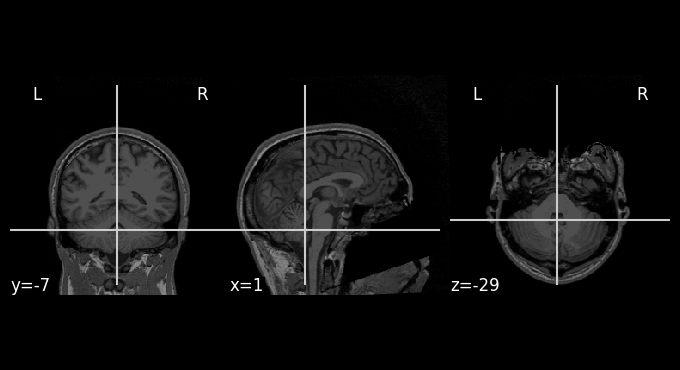

In [12]:
from nilearn import plotting
plotting.plot_anat(t1_fname);
plt.show()

We can also look at the BEM model (the identified surfaces of the BEM):

In [13]:
# This is the path that point to the directory that has the subject folder(s) for the BEM models.
# Here, it is the path that you saved the extra data at.
subjects_dir = f"{extra_path}/freesurfer"

In [21]:
%matplotlib qt
mne.viz.plot_bem(subject="sub-01", subjects_dir=subjects_dir);

Using surface: C:\Users\wmvan\projects\mne_practical_meeg_2025\extra_data_mne\freesurfer\sub-01\bem\inner_skull.surf
Using surface: C:\Users\wmvan\projects\mne_practical_meeg_2025\extra_data_mne\freesurfer\sub-01\bem\outer_skull.surf
Using surface: C:\Users\wmvan\projects\mne_practical_meeg_2025\extra_data_mne\freesurfer\sub-01\bem\outer_skin.surf


## Coregistration 

The next step usually would be to coregister the MRI coordinate system with the MEG coordinate system. This is done to get the sensors into the right relation to the head model for the forward model computation.

For this data set, this is already done, but if you wanted to do this, this is the code to use:

In [23]:
# mne.gui.coregistration(subject='sub-01', subjects_dir=subjects_dir, inst=raw_fname);

### Visualizing the coregistration

The coregistration is the operation that allows to position the head and the sensors in a common coordinate system. 

In the MNE software, the transformation to align the head and the sensors in stored in a so called *trans* file. It is a FIF file that ends with `-trans.fif`. It can be obtained with ``mne_analyze`` (Unix tools), ``mne.gui.coregistration`` (in Python, see above) or mrilab if you're using a Neuromag system.

For the Python version, see https://mne.tools/dev/generated/mne.gui.coregistration.html for the docstring. There is also a video link that shows how to perform coregistration.

Since we assume the coregistration is done, we just visually check the alignment with the following code.

In [24]:
trans_fname = f"{extra_path}/source_recon/sub-01/sub-01-trans.fif"
info = mne.io.read_info(raw_fname)
fig = mne.viz.plot_alignment(info, trans_fname, subject='sub-01', dig=True,
                             subjects_dir=subjects_dir, verbose=True);

auto None sub-01
Using outer_skin.surf for head surface.
Getting helmet for system 306m
Channel types::	grad: 204, mag: 102, eeg: 74


## Compute Source Space

The source space defines the positions of the candidate source locations. The following code computes such a source space with an OCT-6 resolution. 

Note that this is a surface (not volume) source space.

In [25]:
mne.set_log_level('WARNING')
subject = 'sub-01'
src = mne.setup_source_space(subject, spacing='oct6', subjects_dir=subjects_dir,
                             add_dist=False)

In [26]:
src

<SourceSpaces: [<surface (lh), n_vertices=138517, n_used=4098>, <surface (rh), n_vertices=140607, n_used=4098>] MRI (surface RAS) coords, subject 'sub-01', ~20.5 MiB>

`src` contains two parts, one for the left hemisphere (4098 locations) and one for the right hemisphere (4098 locations).

We can visualize the source space together with the head model and also together with the MEG helmet.

In [28]:
mne.viz.plot_alignment(info, trans_fname, subject=subject, dig=False, src=src,
                             subjects_dir=subjects_dir, verbose=True, meg=False,
                             eeg=False);

auto None sub-01
Using outer_skin.surf for head surface.


In [29]:
mne.viz.plot_alignment(info, trans_fname, subject=subject,
                       src=src, subjects_dir=subjects_dir, dig=True,
                       surfaces=['head-dense', 'white'], coord_frame='meg')

head-dense None sub-01


### Compute forward solution

Now we have all the ingredients to compute the forward solution.

To reduce computational load, we'll just compute a single layer BEM
(just inner skull) that can then be used for MEG (but not EEG).

First, we compute the BEM model using `mne.make_bem_solution()`, then we compute the forward solution using `mne.make_forward_solution()`.

In [30]:
conductivity = (0.3,)  # for single layer
# conductivity = (0.3, 0.006, 0.3)  # for three layers
model = mne.make_bem_model(subject=subject, ico=4,
                           conductivity=conductivity,
                           subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)

We can write this solution to disk for later use:

In [31]:
bem_fname = f"{extra_path}/source_recon/sub-01/sub-01-bem.fif"
mne.bem.write_bem_solution(bem_fname, bem, overwrite=True)

Now compute the forward model (this might take a while!):

In [32]:
fwd = mne.make_forward_solution(raw_fname, trans=trans_fname,
                                src=src, bem=bem,
                                meg=True,  # include MEG channels
                                eeg=False,  # exclude EEG channels
                                mindist=5.0,  # ignore sources <= 5mm from inner skull
                                n_jobs=1)  # number of jobs to run in parallel

In [33]:
fwd

<Forward | MEG channels: 306 | EEG channels: 0 | Source space: Surface with 8193 vertices | Source orientation: Free>

In [35]:
leadfield = fwd["sol"]["data"]
n_sensors, n_dipoles = leadfield.shape
print(f"Leadfield size : {n_sensors} sensors x {n_dipoles} dipoles")

Leadfield size : 306 sensors x 24579 dipoles


We also save the forward model for later use:

In [36]:
fwd_fname = f"{extra_path}/source_recon/sub-01/sub-01-meg-fwd.fif"
mne.write_forward_solution(fwd_fname, fwd, overwrite=True)

## Compute and show sensitivy maps

Let's compute a sensitivity map for gradiometers, we asked for the dipole orientation to be fixed.

In [37]:
sens_map = mne.sensitivity_map(fwd, ch_type="grad", mode="fixed")

Let's view in 3D:

In [38]:
# enable correct backend for 3d plotting
clim = dict(kind="percent", lims=(0.0, 50, 99), smoothing_steps=3)  # let's see single dipoles
brain = sens_map.plot(subject=subject, time_label="GRAD sensitivity",
                      subjects_dir=subjects_dir, clim=clim, smoothing_steps=8);
brain.show_view("lat")

<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>Compute and plot the sensitivity maps for magnetometers and compare it with the gradiometers. </li>
      <li>Can you justify the claims that MEG is not sensitive to radial sources?</li>     
      <li>Try changing the `mode` parameter in `mne.sensitivity_map` and see how fixed or free orientation forward operator change the pictures. Comment.</li>
    </ul>
</div>